<a href="https://colab.research.google.com/github/lbenit/Floristic_map_africa/blob/main/09_Random_forest_continuous.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/lbenit/Floristic_map_africa.git


Cloning into 'Floristic_map_africa'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 1.35 MiB | 2.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
%cd Floristic_map_africa


/content/Floristic_map_africa/Floristic_map_africa


In [ ]:
# Print working directory
import os
print(os.getcwd())

/content/Floristic_map_africa/Floristic_map_africa


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

# Load data

In [3]:
# Load in test train
embedding_test=pd.read_csv('Data/test_df.csv')
embedding_train=pd.read_csv('Data/train_df.csv')

In [4]:
targets=['UMAP1','UMAP2','UMAP3']

# Basic RF

In [10]:
predictors=['bio12','bio04','bio16','hnd','cluster4','fire_frequency','bio01','cec_mean_0_20']

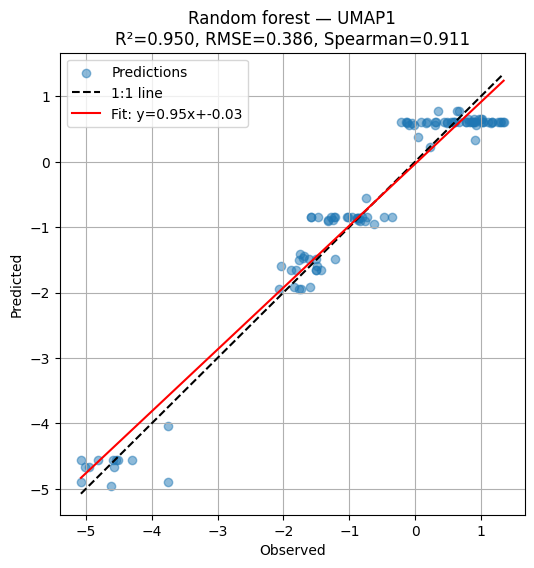

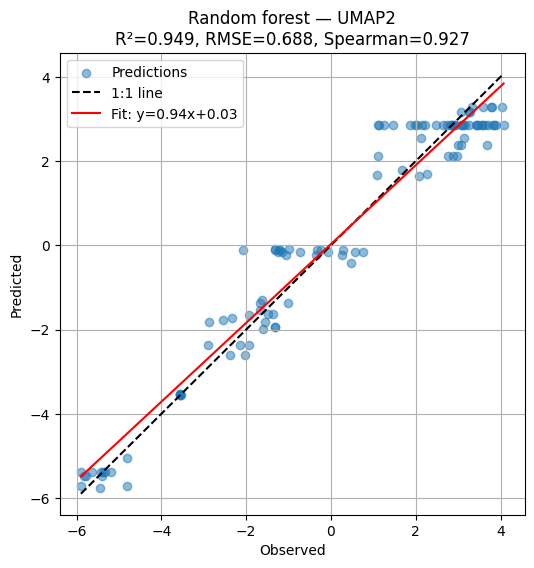

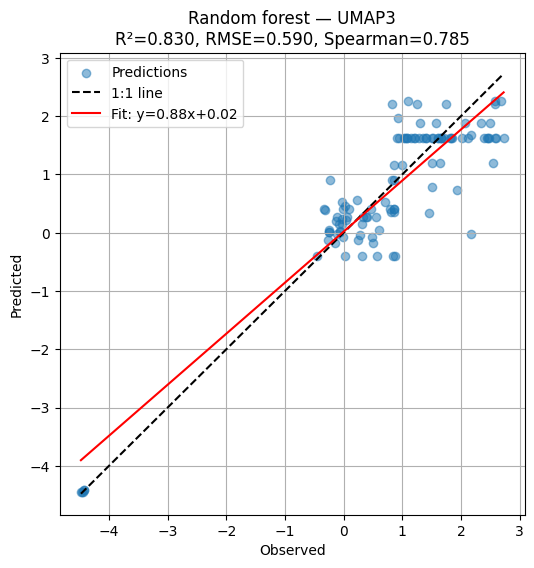

In [13]:

# Prepare empty containers
results_list = []

train_preds_df = pd.DataFrame(index=embedding_train.index)
test_preds_df  = pd.DataFrame(index=embedding_test.index)


for target in targets:

    # --- Prepare data ---
    X_train = embedding_train[predictors]
    y_train = embedding_train[target]

    X_test  = embedding_test[predictors]
    y_test  = embedding_test[target]

    # --- Train RF on ALL predictors ---
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # --- Predict ---
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    train_preds_df[target] = y_pred_train
    test_preds_df[target]  = y_pred_test

    # --- Metrics ---
    r2   = r2_score(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Spearman rank correlation
    spearman_corr, spearman_p = spearmanr(y_test, y_pred_test)

    # --- Linear regression for slope/intercept ---
    lr = LinearRegression()
    lr.fit(y_test.values.reshape(-1,1), y_pred_test.reshape(-1,1))

    slope = lr.coef_[0][0]
    intercept = lr.intercept_[0]

    # --- Store results ---
    results_list.append({
        "Target": target,
        "R2": r2,
        "RMSE": rmse,
        "Spearman": spearman_corr,
        "Spearman_p": spearman_p,
        "Slope": slope,
        "Intercept": intercept,
        "Model": model,
        "TopVars": predictors  # now simply all predictors
    })

    # --- Plot ---
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred_test, alpha=0.5, label="Predictions")

    min_val = min(y_test.min(), y_pred_test.min())
    max_val = max(y_test.max(), y_pred_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label="1:1 line")

    x_line = np.linspace(min_val, max_val, 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r-', label=f"Fit: y={slope:.2f}x+{intercept:.2f}")

    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(
        f"Random forest — {target}\n"
        f"R²={r2:.3f}, RMSE={rmse:.3f}, Spearman={spearman_corr:.3f}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

# Convert results list to DataFrame
results_df = pd.DataFrame(results_list)


# All variable RF and select top 25 variables

In [14]:
# All variables except soil
predictors= ['fire_frequency','EVI_mean', 'EVI_median', 'EVI_max', 'EVI_min', 'EVI_stdDev', 'EVI_p5', 'EVI_p95', 'B9_mean', 'B9_median', 'B9_max', 'B9_min', 'B9_stdDev', 'B9_p5', 'B9_p95', 'B11_mean', 'B11_median', 'B11_max', 'B11_min', 'B11_stdDev', 'B11_p5', 'B11_p95', 'B12_mean', 'B12_median', 'B12_max', 'B12_min', 'B12_stdDev', 'B12_p5', 'B12_p95', 'B1_mean', 'B1_median', 'B1_max', 'B1_min', 'B1_stdDev', 'B1_p5', 'B1_p95', 'B2_mean', 'B2_median', 'B2_max', 'B2_min', 'B2_stdDev', 'B2_p5', 'B2_p95', 'B3_mean', 'B3_median', 'B3_max', 'B3_min', 'B3_stdDev', 'B3_p5', 'B3_p95', 'B4_mean', 'B4_median', 'B4_max', 'B4_min', 'B4_stdDev', 'B4_p5', 'B4_p95', 'B5_mean', 'B5_median', 'B5_max', 'B5_min', 'B5_stdDev', 'B5_p5', 'B5_p95', 'B6_mean', 'B6_median', 'B6_max', 'B6_min', 'B6_stdDev', 'B6_p5', 'B6_p95', 'B7_mean', 'B7_median', 'B7_max', 'B7_min', 'B7_stdDev', 'B7_p5', 'B7_p95', 'B8_mean', 'B8_median', 'B8_max', 'B8_min', 'B8_stdDev', 'B8_p5', 'B8_p95', 'bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08', 'bio09', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'Greenup', 'MidGreenup', 'Peak', 'Maturity', 'Senescence', 'MidGreendown', 'Dormancy', 'EVI_Minimum', 'EVI_Amplitude', 'EVI_Area', 'tpi', 'hnd']

In [15]:
clusters_test = embedding_test['cluster4']
clusters_train = embedding_train['cluster4']


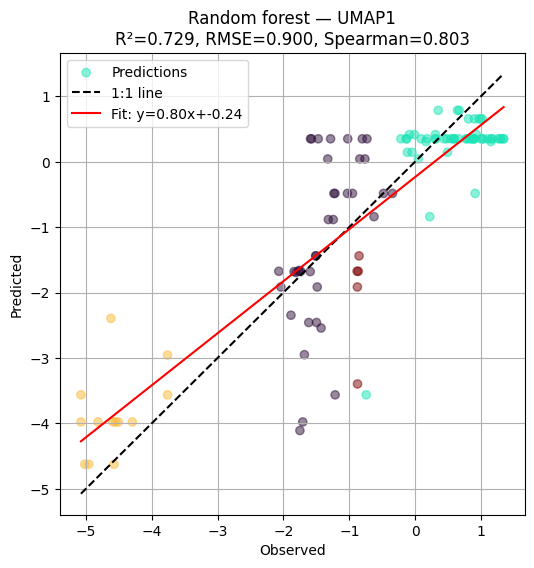

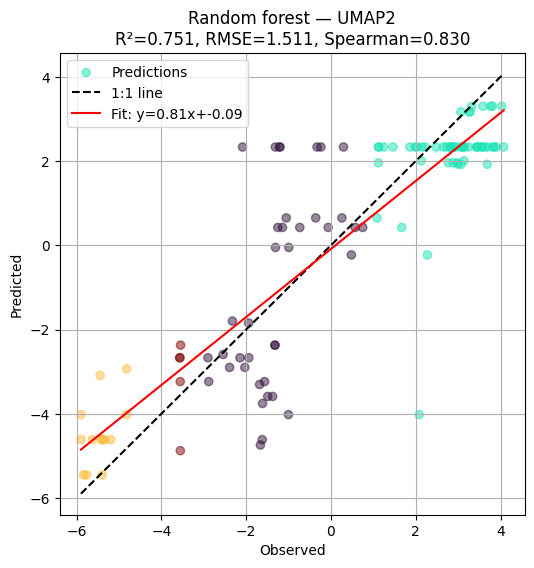

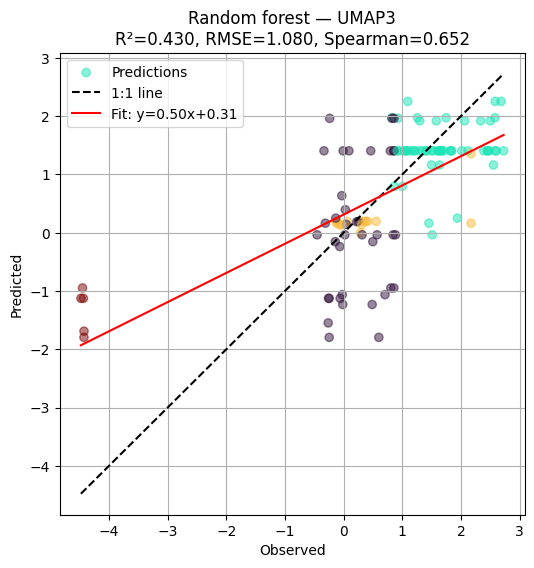

{'UMAP1': ['bio13',
  'bio16',
  'bio06',
  'bio04',
  'bio12',
  'bio15',
  'bio02',
  'bio07',
  'EVI_Area',
  'bio08',
  'bio10',
  'EVI_max',
  'bio05',
  'EVI_median',
  'EVI_p5',
  'EVI_min',
  'B11_max',
  'B4_max',
  'B5_p95',
  'B12_p5',
  'hnd',
  'B2_p95',
  'B11_stdDev',
  'B12_stdDev',
  'B7_p5'],
 'UMAP2': ['bio16',
  'bio12',
  'bio13',
  'bio15',
  'bio06',
  'bio02',
  'bio05',
  'bio07',
  'bio08',
  'bio10',
  'bio04',
  'bio01',
  'EVI_max',
  'B5_min',
  'B12_p5',
  'bio18',
  'EVI_min',
  'B2_p95',
  'B1_min',
  'MidGreendown',
  'hnd',
  'B6_p5',
  'bio09',
  'B6_min',
  'Greenup'],
 'UMAP3': ['bio12',
  'B4_p95',
  'B3_p95',
  'B2_p95',
  'bio01',
  'B2_stdDev',
  'B1_p95',
  'EVI_p5',
  'B3_stdDev',
  'B1_stdDev',
  'bio04',
  'bio13',
  'bio09',
  'tpi',
  'bio07',
  'bio17',
  'bio19',
  'bio15',
  'B6_p95',
  'bio14',
  'EVI_Area',
  'B8_max',
  'B5_stdDev',
  'hnd',
  'B12_max']}

In [16]:
# Prepare empty containers
results_list = []
best_variables = {}

train_preds_df = pd.DataFrame(index=embedding_train.index)
test_preds_df  = pd.DataFrame(index=embedding_test.index)

TOP_K = 25

for target in targets:

    # --- Prepare data ---
    X_train_full = embedding_train[predictors]
    y_train = embedding_train[target]

    X_test_full  = embedding_test[predictors]
    y_test  = embedding_test[target]

    # --- First RF for variable importance ---
    rf_full = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    rf_full.fit(X_train_full, y_train)

    # --- Rank variables by importance ---
    importances = pd.Series(rf_full.feature_importances_, index=predictors)
    top_vars = importances.sort_values(ascending=False).head(TOP_K).index.tolist()
    best_variables[target] = top_vars

    # --- Train final RF using only selected variables ---
    X_train = X_train_full[top_vars]
    X_test  = X_test_full[top_vars]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # --- Predict ---
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    train_preds_df[target] = y_pred_train
    test_preds_df[target]  = y_pred_test

    # --- Metrics ---
    r2   = r2_score(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Spearman rank correlation
    spearman_corr, spearman_p = spearmanr(y_test, y_pred_test)

    # --- Linear regression for slope/intercept ---
    lr = LinearRegression()
    lr.fit(y_test.values.reshape(-1,1), y_pred_test.reshape(-1,1))

    slope = lr.coef_[0][0]
    intercept = lr.intercept_[0]

    # --- Store results ---
    results_list.append({
        "Target": target,
        "R2": r2,
        "RMSE": rmse,
        "Spearman": spearman_corr,
        "Spearman_p": spearman_p,
        "Slope": slope,
        "Intercept": intercept,
        "Model": model,
        "TopVars": top_vars
    })

    # --- Plot ---
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred_test, alpha=0.5, label="Predictions",
                c=clusters_test, cmap='turbo')

    min_val = min(y_test.min(), y_pred_test.min())
    max_val = max(y_test.max(), y_pred_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label="1:1 line")

    x_line = np.linspace(min_val, max_val, 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r-', label=f"Fit: y={slope:.2f}x+{intercept:.2f}")

    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(
        f"Random forest — {target}\n"
        f"R²={r2:.3f}, RMSE={rmse:.3f}, Spearman={spearman_corr:.3f}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

# Convert results list to DataFrame
results_df = pd.DataFrame(results_list)

best_variables


In [17]:
train_preds_df.head()

,UMAP1,UMAP2,UMAP3
0,0.348369,2.333690,1.404690
1,0.306095,2.006566,0.793137
2,0.348369,2.333690,1.404690
3,0.348369,2.333690,1.404690
4,0.348369,2.333690,1.404690
